# Train an imputation model

Loss here is the same as scvi loss. We want to do see if scvi with huge dropout is similar to imputation loss with 0.5 noise2self

In this notebook, for a fair comparison, we mask half and predict on the rest for the all the masking probabilities tested. For example, even if masking probability is 3%, we train using the 3% masking probability. However, when testing we mask 50% and predict on the other half.

Follow this example: https://cellarium-ai.github.io/cellarium-ml/tutorials/part_i.html

In [2]:
from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.data import read_h5ad_file
from cellarium.ml.data import DistributedAnnDataCollection
from cellarium.ml.utilities.data import AnnDataField, collate_fn, densify, categories_to_codes
from cellarium.ml.callbacks import PredictionWriter
from cellarium.ml.data.dadc_dataset import IterableDistributedAnnDataCollectionDataset

from cellarium.ml.models import ImputationModel, SingleCellVariationalInference

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import anndata as ad
import glob
import os
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
import seaborn as sns
import shutil
import pickle

# Functions

In [18]:
def plot_train_loss(csv_path, prob=""):
    """
    Plot training loss per epoch from a PyTorch Lightning CSV logger file.

    Parameters
    ----------
    csv_path : str
        Path to metrics.csv file (e.g. "logs/scvi/version_0/metrics.csv")
    """
    # Load and clean data
    df = pd.read_csv(csv_path)
    df_epoch = df.dropna(subset=["epoch", "train_loss"]).copy()
    df_epoch["epoch"] = df_epoch["epoch"].astype(int)
    df_epoch["train_loss"] = df_epoch["train_loss"].astype(float)
    df_epoch = df_epoch.sort_values("epoch")

    # Plot loss vs epoch
    plt.figure(figsize=(8, 5))
    plt.plot(df_epoch["epoch"], df_epoch["train_loss"], marker="o", linewidth=2)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Training Loss", fontsize=12)
    plt.title("Training Loss per Epoch " + str(prob) , fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

In [19]:
def reconstruct_anndata_from_latent(data_path, module, layer_key="reconstructed"):
    """
    Reconstruct AnnData from latent representation using the SCVI or Imputation model.

    Parameters
    ----------
    data_path : str
        Path to the data file.   
    module : CellariumModule
        Trained CellariumModule containing the SCVI model or Imputation model.
    collated_predictions : dict
        Dictionary containing batch indices from predictions.

    Returns
    -------
    AnnData
        Updated AnnData object with reconstructed data stored in the specified layer.
    """

    # Get the anndata object
    adata_run = read_h5ad_file(data_path)

    # Create a dataset for reconstruction
    dataset = IterableDistributedAnnDataCollectionDataset(
        adata_run,
        batch_keys={
            "x_ng": AnnDataField(attr="X", convert_fn=densify),
            "var_names_g": AnnDataField(attr="var_names"),
            "batch_index_n": AnnDataField(attr="obs", key="batch", convert_fn=categories_to_codes),
        },
        batch_size=128, # Taken from default in scvi_demo_get_batched_data.ipynb
        shuffle=False,
        shuffle_seed=0,
        drop_last_indices=False,
    )

    # Prepare to collect reconstructed sparse matrices
    sparse_coos = []

    # Reconstruct in batches
    with torch.no_grad():
        for batch in dataset:
            gene_inds = np.arange(len(batch["var_names_g"]))
            batch_index_n = torch.tensor(batch["batch_index_n"]).long()
            x_ng = torch.tensor(batch["x_ng"], dtype=torch.float32)
            counts_ng = module.model.reconstruct(
                                x_ng,
                                var_names_g=batch["var_names_g"],
                                gene_inds=gene_inds,
                                batch_index_n=batch_index_n,
                                transform_batch=None, #the model reconstructs using the observed batch
                                use_importance_sampling=True
                                )
            counts_np = counts_ng["x_ng"].cpu().numpy()
            sparse_coos.append(sp.csr_matrix(counts_np))

    # make the final sparse matrix and keep it as a layer
    csr = sp.vstack(sparse_coos).tocsr()
    adata_run.layers[layer_key] = csr
    
    print(adata_run)

    return adata_run

In [20]:
def reconstruct_anndata_with_masked_indices(
    data_path: str,
    module: CellariumModule,
    masked_indices_list,
    layer_key: str = "reconstructed_masked_only",
    batch_size: int = 128,
    use_importance_sampling: bool = True,
    n_latent_samples: int = 1,
) -> ad.AnnData:
    """
    Parameters
    ----------
    data_path : str
        Path to the original anndata file used for the run (so batches/ordering match).
    module : CellariumModule
        Trained module with `.model.reconstruct(...)`.
    masked_indices_list : Sequence
        Length n_cells; each entry is either an array-like of gene indices or a CSV string "1,4,9".
    layer_key : str
        Name of the new layer to store reconstructed-only matrix.
    batch_size : int
        Batch size for reconstruction.
    use_importance_sampling : bool
        Pass-through to `model.reconstruct`.
    n_latent_samples : int
        Number of latent samples for reconstruction.
    Returns
    -------
    AnnData
        Copy of the original AnnData with `adata.layers[layer_key]` containing a sparse matrix
        that equals the original counts but with masked entries replaced by reconstructed values.
    """
    
    # load the anndata used for data ordering
    adata_run = read_h5ad_file(data_path)

    # prepare dataset iterator (same as other helpers)
    dataset = IterableDistributedAnnDataCollectionDataset(
        adata_run,
        batch_keys={
            "x_ng": AnnDataField(attr="X", convert_fn=densify),
            "var_names_g": AnnDataField(attr="var_names"),
            "batch_index_n": AnnDataField(attr="obs", key="batch", convert_fn=categories_to_codes),
        },
        batch_size=batch_size,
        shuffle=False,
        shuffle_seed=0,
        drop_last_indices=False,
    )

    # we'll build a dense reconstructed matrix then mask into original
    recon_rows = []
    row_ptr = 0
    with torch.no_grad():
        for batch in dataset:
            gene_inds = np.arange(len(batch["var_names_g"]))
            batch_index_n = torch.tensor(batch["batch_index_n"]).long()
            x_ng = torch.tensor(batch["x_ng"], dtype=torch.float32)

            counts_ng = module.model.reconstruct(
                x_ng,
                var_names_g=batch["var_names_g"],
                gene_inds=gene_inds,
                batch_index_n=batch_index_n,
                transform_batch=None,
                use_importance_sampling=use_importance_sampling,
                n_latent_samples=n_latent_samples,
            )
            counts_np = counts_ng["x_ng"].cpu().numpy()

            # for each cell in batch, copy only masked indices; otherwise keep original
            for i in range(counts_np.shape[0]):
                cell_idx = row_ptr + i
                masked_inds = masked_indices_list[cell_idx]
                # start with original dense row
                if sp.issparse(adata_run.X):
                    orig_row = adata_run.X[cell_idx].toarray().ravel()
                else:
                    orig_row = np.asarray(adata_run.X[cell_idx], dtype=float).ravel()
                if masked_inds.size > 0:
                    orig_row[masked_inds] = counts_np[i, masked_inds]
                recon_rows.append(sp.csr_matrix(orig_row))
            row_ptr += counts_np.shape[0]

    csr = sp.vstack(recon_rows).tocsr()
    adata_out = adata_run.copy()
    adata_out.layers[layer_key] = csr
    return adata_out

In [21]:
def mask_data(adata, masking_probability, random_seed):
    """
    Randomly mask a fraction of genes per cell in an AnnData object.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object (n_obs x n_vars).
    mask_fraction : float
        Fraction of genes to mask per cell (e.g., 0.2 = 20%).
    mask_value : float or np.nan
        Value to assign to masked positions (default 0.0).
    layer_key : str
        Key in adata.layers where masked data will be stored.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    masked_adata : AnnData
        New AnnData object with:
          - masked counts in `.X` and `.layers[layer_key]`
          - mask matrix in `.layers[f"mask_{int(masking_probability*100)}"]`
          - per-cell mask indices in `.obs[f"masked_gene_indices_{int(masking_probability*100)}"]`
    """

    rng = np.random.default_rng(random_seed)
    
    n_cells, n_genes =  adata.X.shape
    n_mask = int(masking_probability * n_genes)
    print(f"Masking {n_mask} genes out of {n_genes} ({masking_probability*100}%) per cell.")
    
    # Create mask matrix of all zeros of shape (n_cells, n_genes)
    mask = np.zeros(adata.X.shape, dtype=bool)
  
    masked_indices_per_cell = []
    # For each cell, randomly select n_mask gene indices to mask
    for i in range(n_cells):
        # print(f"Processing cell {i+1}/{n_cells}")
        # Randomly choose n_mask unique gene indices
        mask_indices = rng.choice(n_genes, n_mask, replace=False)
        mask[i, mask_indices] = True
        masked_indices_per_cell.append(mask_indices)

    X_masked = adata.X.copy()
    # Apply the mask: set masked positions to 0
    X_masked[mask] = 0

    # Create new AnnData to store masked data and mask matrix
    masked_adata = ad.AnnData(X_masked, obs=adata.obs.copy(), var=adata.var.copy())
    masked_adata.layers["X_masked"] = X_masked
    masked_adata.layers[f"mask_{int(masking_probability*100)}"] = mask.astype(np.int8)
    masked_adata.obsm = adata.obsm.copy()

    # Store which gene indices were masked per cell (as strings for convenience)
    masked_adata.obs[f"masked_gene_indices_{int(masking_probability*100)}"] = [
        ",".join(map(str, idxs)) for idxs in masked_indices_per_cell
    ]

    # Create DataModule for masked data
    dm_mask= CellariumAnnDataDataModule(
            dadc=masked_adata,
            batch_keys={
                "x_ng": AnnDataField(attr="X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch", convert_fn=categories_to_codes),
            },
            batch_size=512,
            shuffle=False,
        )  

    return masked_adata, dm_mask, masked_indices_per_cell

In [22]:
def save_predictions_latent(predictions, prediction_path, adata, label, prob):
    """
    Save prediction latent representations with proper labeling.
    
    Parameters
    ----------
    predictions : list
        List of prediction batches
    prediction_path : str
        Base path for saving predictions
    adata : AnnData
        AnnData object to store results
    label : str
        Label for the predictions ('whole' or 'masked')
    prob : float
        Masking probability used
    """

    # Create subdirectory for this prediction type
    pred_path = os.path.join(prediction_path, label)
    os.makedirs(pred_path, exist_ok=True)
    
    # Load and combine all batches
    dfs = []
    for file in glob.glob(os.path.join(prediction_path, f'batch_*')):
        dfs.append(pd.read_csv(file, index_col=0, header=None))
    latent_df = pd.concat(dfs, axis=0)
    latent_df = latent_df.loc[adata.obs_names]
    
    # Move batch files in prediction_path to pred_path
    batch_files = glob.glob(os.path.join(prediction_path, f'batch_*'))

    for src in batch_files:
        base = os.path.basename(src)
        dest = os.path.join(pred_path, base)
        try:
            shutil.move(src, dest)
        except Exception:
            if os.path.exists(dest):
                try:
                    os.remove(dest)
                except Exception as e:
                    raise RuntimeError(f"Could not remove existing destination {dest}: {e}") from e
            shutil.move(src, dest)

    return latent_df.values

def train_and_predict_imputation(imputation_module, adata, dm, masking_prob, prediction_base_path='runs/imputation'):
    """
    Train imputation model and perform both whole dataset and masked predictions.
    
    Parameters
    ----------
    imputation_module : CellariumModule
        Imputation model to be trained
    adata : AnnData
        Input dataset
    dm : CellariumAnnDataDataModule
        Data module for training
    masking_prob : float
        Probability for masking genes
    prediction_base_path : str
        Base path for storing predictions
        
    Returns
    -------
    dict
        Dictionary containing whole and masked predictions, 
        whole and masked latent representations, 
        and masked gene indices.
    """

    # Setup paths and names
    name_label = f"mask{int(masking_prob*100)}"
    prediction_path = f"{prediction_base_path}/predictions_{name_label}"
    
    # Define imputation module
    print(f"\nDefining imputation module with masking_probability={masking_prob}")
    # Train model
    print(f"Training model...")
    logger = CSVLogger("logs", name=f"imputation_{name_label}")
    trainer = pl.Trainer(
        accelerator="cpu",
        precision="32-true",
        devices=1,
        max_epochs=20,
        default_root_dir=f"{prediction_base_path}/imputation_{name_label}/",
        logger=logger,
        callbacks=[PredictionWriter(output_dir=prediction_path)])
    trainer.fit(imputation_module, dm)
    
    # Get metrics from the trained model
    imputation_module.eval()
    batch = next(iter(dm.train_dataloader()))
    batch = {k: v for k, v in batch.items() if k in {"x_ng", "batch_index_n","var_names_g"}}
    print(batch.keys())
    with torch.no_grad():
        metric_outputs = imputation_module.model(**batch)
    print(f"Loss: {metric_outputs['loss'].item():.4f}")
    print(f"Reconstruction Loss: {metric_outputs['reconstruction_loss'].mean().item():.4f}")
    print(f"KL Divergence Z: {metric_outputs['kl_divergence_z'].mean().item():.4f}")
    print(f"KL Annealing Weight: {metric_outputs['kl_annealing_weight']:.4f}")

    # Predict on the whole dataset
    print("Predicting on whole dataset...")
    whole_predictions = trainer.predict(imputation_module, dm)
    whole_collated = collate_fn(whole_predictions)
    latent_whole = save_predictions_latent(whole_collated, prediction_path, adata, 'whole', masking_prob)

    # Create and predict on masked dataset
    print("Predicting on masked dataset...")
    masked_adata, dm_mask, masked_indices = mask_data(dm.dadc, masking_probability=0.5, random_seed=42)
    masked_predictions = trainer.predict(imputation_module, dm_mask)
    masked_collated = collate_fn(masked_predictions)
    latent_masked = save_predictions_latent(masked_collated, prediction_path, adata, 'masked', masking_prob)    
    
    return {
        f"{name_label}_whole": whole_collated,
        f"{name_label}_masked": masked_collated,
        f"{name_label}_latent_whole": latent_whole,
        f"{name_label}_latent_masked":latent_masked,
        f"{name_label}_masked_gene_indices": masked_indices,
        f"{name_label}_output_metrics": metric_outputs
    }


# CellariumAnnDataDataModule for 10k pbmc count data


In [11]:
data_path = "/Users/aseelawdeh/Documents/stephen_scvi/pbmc_count.h5ad"
adata = read_h5ad_file(data_path)

In [12]:
dm = CellariumAnnDataDataModule(
            dadc = adata,
            batch_keys={
                "x_ng": AnnDataField(attr="raw.X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch",convert_fn=categories_to_codes)
                },
            batch_size=512,
            shuffle=False,
            #shuffle_seed=0
        )

# Imputation Model 

In [13]:
collated_predictions = {}

In [16]:
# Train imputation models with different masking probabilities and save predictions in separate folders
noise2self_ratio = 0.5
#masking_probs = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.5, 0.7, 0.9]
masking_probs = [0.5]
for prob in masking_probs:
    print(f"\nProcessing masking probability: {prob}")

    # Create a fresh copy of adata for this masking probability
    adata_run = adata.copy()

    # Define imputation module
    imputation_module = CellariumModule(
        model=ImputationModel(
            var_names_g=dm.dadc.var_names,
            n_batch=10,
            n_latent=20,
            masking_probability=prob,
            noise2self_ratio=noise2self_ratio,
            encoder={
                "hidden_layers": [
                    {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                ],
                "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
            },
            decoder={
                "hidden_layers": [
                    {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                ],
                "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                "final_additive_bias": False,
            },
            dropout_rate=0.1,
            dispersion="gene",
            log_variational=True,
            gene_likelihood="nb",
            latent_distribution="normal"
        ),
        optim_fn=torch.optim.AdamW,
        optim_kwargs={"lr": 1e-4}
    )

    # Train and get predictions for this masking probability
    # Predictions includes: "{name_label}_whole", "{name_label}_masked", "{name_label}_latent_whole", "{name_label}_latent_masked", "{name_label}_masked_gene_indices"
    predictions = train_and_predict_imputation(imputation_module, adata_run, dm, prob)

    # Store predictions in our collection
    name_label = f"mask{int(prob*100)}"
    
    # Only add the whole and masked predictions to collated_predictions
    collated_predictions[f"{name_label}_whole"] = predictions[f"{name_label}_whole"]
    collated_predictions[f"{name_label}_masked"] = predictions[f"{name_label}_masked"]

    # Reconstruct data for whole predictions using reconstruct_anndata_from_latent
    adata_reconstructed_whole = reconstruct_anndata_from_latent(
            data_path, 
            imputation_module, 
            layer_key=f"reconstructed_whole" 
        )

    # Reconstruct data for masked predictions using reconstruct_anndata_from_latent
    adata_reconstructed_masked = reconstruct_anndata_from_latent(
        data_path, 
        imputation_module, 
        layer_key=f"reconstructed_masked", 
    )

    # Save the separate anndata object for this masking probability
    outdir = f"runs/imputation_scvi/mask_{int(prob*100)}"
    os.makedirs(outdir, exist_ok=True)

    adata_run.write_h5ad(f"{outdir}/imputation.h5ad")
    adata_reconstructed_whole.write_h5ad(f"{outdir}/imputation_reconstructed_whole.h5ad")
    adata_reconstructed_masked.write_h5ad(f"{outdir}/imputation_reconstructed_masked.h5ad")

    with open(f"{outdir}/predictions.pkl", "wb") as f:
        pickle.dump(predictions, f)
    
    torch.save(imputation_module.state_dict(), f"{outdir}/model.pt")

    print(f"Finished run for prob={prob}, saved to {outdir}")
    print(f"AnnData object saved with obsm keys: {list(adata_run.obsm.keys())}")



Processing masking probability: 0.5
ImputationModel(
  (z_encoder): EncoderSCVI(
    (fully_connected): FullyConnectedWithBatchArchitecture(
      (module_list): ModuleList(
        (0): DressedLayer(
          (layer): Linear(in_features=4000, out_features=128, bias=True)
          (dressing): Sequential(
            (0): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (mean_encoder): Linear(in_features=128, out_features=20, bias=True)
    (var_encoder): Linear(in_features=128, out_features=20, bias=True)
  )
  (decoder): DecoderSCVI(
    (fully_connected): FullyConnectedWithBatchArchitecture(
      (module_list): ModuleList(
        (0): DressedLayer(
          (layer): Linear(in_features=20, out_features=128, bias=True)
          (dressing): Sequential(
            (0): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aseelawdeh/Documents/stephen_scvi/imputation/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1.0 M  | train
-------------------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.162     Total estimated model params size (MB)
23        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/aseelawdeh/Documents/stephen_scvi/imputation/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/aseelawdeh/Documents/repos/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/Users/aseelawdeh/Documents/stephen_scvi/imputation/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/Users/aseelawdeh/Documents/stephen_scvi/imputation/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination wit

Training: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/Users/aseelawdeh/Documents/repos/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/Users/aseelawdeh/Documents/repos/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(


AnnData object with n_obs × n_vars = 31774 × 4000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'condition', 'concat'
    layers: 'reconstructed_whole'


/Users/aseelawdeh/Documents/repos/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(


AnnData object with n_obs × n_vars = 31774 × 4000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'condition', 'concat'
    layers: 'reconstructed_masked'
Finished run for prob=0.5, saved to runs/imputation_scvi/mask_50
AnnData object saved with obsm keys: []


In [12]:
collated_predictions.keys()

dict_keys(['x_ng', 'var_names_g', 'obs_names_n', 'batch_index_n'])

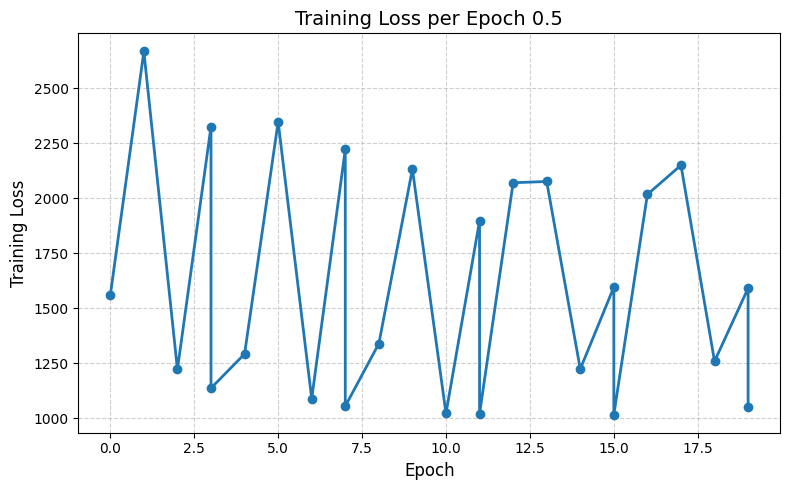

In [23]:
# Plot training loss
masking_probs = [0.5]#[0.05, 0.1, 0.2, 0.5, 0.7]# 0.9]
for prob in masking_probs:
    name_label=f"mask{int(prob*100)}"
    plot_train_loss("logs/imputation_" + name_label + "/version_7/metrics.csv", prob)


# Visualizations (not masked)

In [ ]:
# Read anndata object with all layers, etc
adata = read_h5ad_file("runs/imputation_scvi/imputation_reconstructed_mask50.h5ad") 

In [8]:
sc.set_figure_params(fontsize=14, vector_friendly=True)

## RAW data (no scvi)

In [16]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_pcs=20, n_neighbors=15, metric="euclidean", method="umap")
sc.tl.umap(adata)
adata.obsm["X_raw_umap"] = adata.obsm["X_umap"].copy()

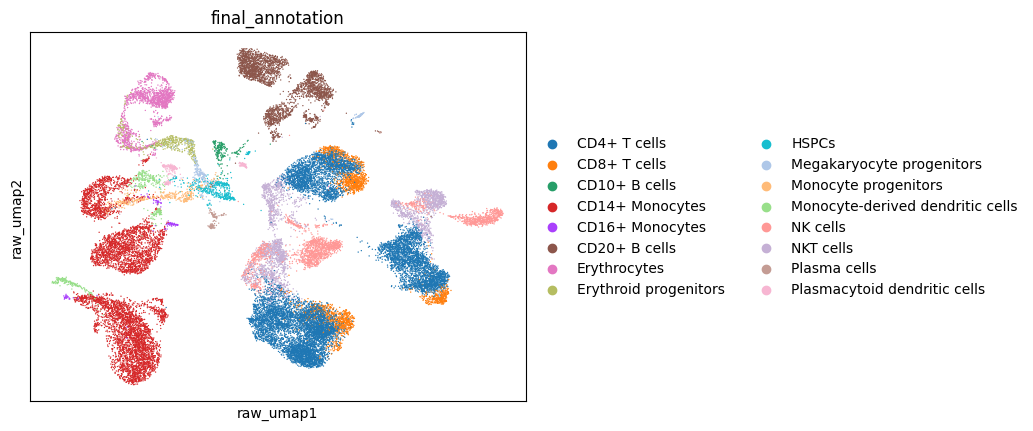

In [17]:
sc.pl.embedding(adata, basis="raw_umap", color=["final_annotation"], ncols=1)

## after scvi

umap visualization of latent space. these represent cell level embeddings (compressed representations capturing biological structure while removing batch noise.)

visualize how the model organizes cells in the latent space



In [22]:
# build a neightbors graph and UMAP based on the scvi latent representation
sc.pp.neighbors(adata, use_rep="X_scvi", n_neighbors=15, metric="euclidean", method="umap")
sc.tl.umap(adata)
adata.obsm["X_scvi_umap"] = adata.obsm["X_umap"].copy()

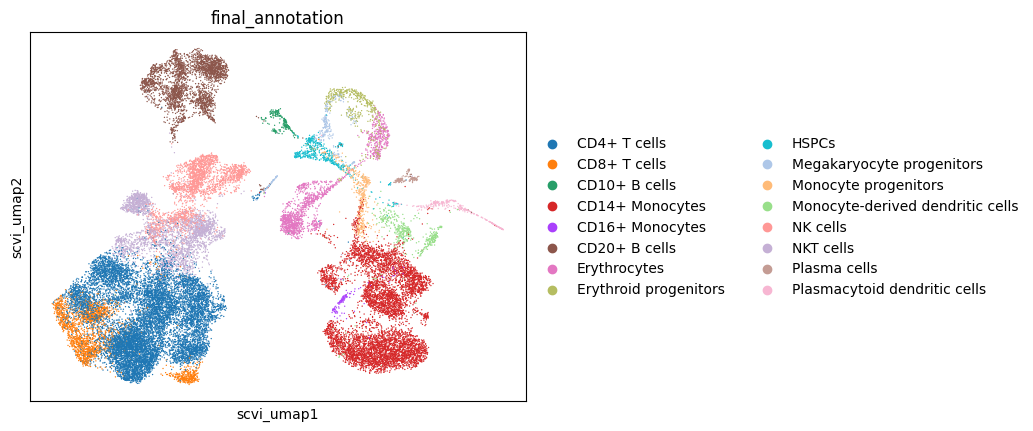

In [23]:
sc.pl.embedding(adata, basis="scvi_umap", color=["final_annotation"], ncols=1)

## UMAPS of latent representation after imputation 

In [24]:
def compute_knn_expression_metrics(adata, use_rep='X', n_top_neighbors=15, n_top_genes=50):
    """
    Compute mean correlation distance between each cell and its kNN neighbors.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data object with computed neighbors
    use_rep : str
        Which representation to use for correlation ('X' for raw/normalized counts)
    n_top_neighbors : int
        Number of neighbors to consider
    
    Returns:
    --------
    correlations : np.ndarray
        Mean correlation for each cell (n_cells,)
    """
    # Get the kNN distances matrix (sparse)
    distances = adata.obsp['distances']
    
    # Get expression matrix
    if use_rep == 'X':
        X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
    else:
        X = adata.obsm[use_rep]
    
    n_cells = adata.n_obs
    correlations = np.zeros(n_cells)
    jaccard_indices = np.zeros(n_cells)
    distances_expr = np.zeros(n_cells)
    
    for i in range(n_cells):
        # Get k nearest neighbors (excluding self)
        neighbors_idx = distances[i].nonzero()[1][:n_top_neighbors]
        
        if len(neighbors_idx) == 0:
            correlations[i] = np.nan
            continue
        
        # Compute pairwise correlations with neighbors
        cell_expr = X[i]
        neighbor_corrs = []
        neighbor_dists = []
        jaccards = []

        # Get top genes for this cell
        cell_top_genes = set(np.argsort(X[i])[-n_top_genes:])
        
        for neighbor_idx in neighbors_idx:
            neighbor_expr = X[neighbor_idx]
            neighbor_top_genes = set(np.argsort(X[neighbor_idx])[-n_top_genes:])

            corr, _ = pearsonr(cell_expr, neighbor_expr) 
            dist = euclidean(cell_expr, neighbor_expr)
            jaccard = len(cell_top_genes & neighbor_top_genes) / len(cell_top_genes | neighbor_top_genes)

            neighbor_corrs.append(corr)
            neighbor_dists.append(dist)
            jaccards.append(jaccard)
        
        correlations[i] = np.mean(neighbor_corrs)
        distances_expr[i] = np.mean(neighbor_dists)
        jaccard_indices[i] = np.mean(jaccards)
    
    return correlations, distances_expr, jaccard_indices

Computing kNN graph for masking probability 0.5...
Computing kNN expression correlations for masking probability 0.5...


/var/folders/vv/z6gg91c17fv4f2g9vzyk4hgh0000gn/T/ipykernel_20771/340585105.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_scores_corr = (adata.obs.groupby("final_annotation")["knn_expression_correlation"].mean())
/var/folders/vv/z6gg91c17fv4f2g9vzyk4hgh0000gn/T/ipykernel_20771/340585105.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_scores_dist = (adata.obs.groupby("final_annotation")["knn_expression_distance"].mean())
/var/folders/vv/z6gg91c17fv4f2g9vzyk4hgh0000gn/T/ipykernel_20771/340585105.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to

Computing UMAP for masking probability 0.5...


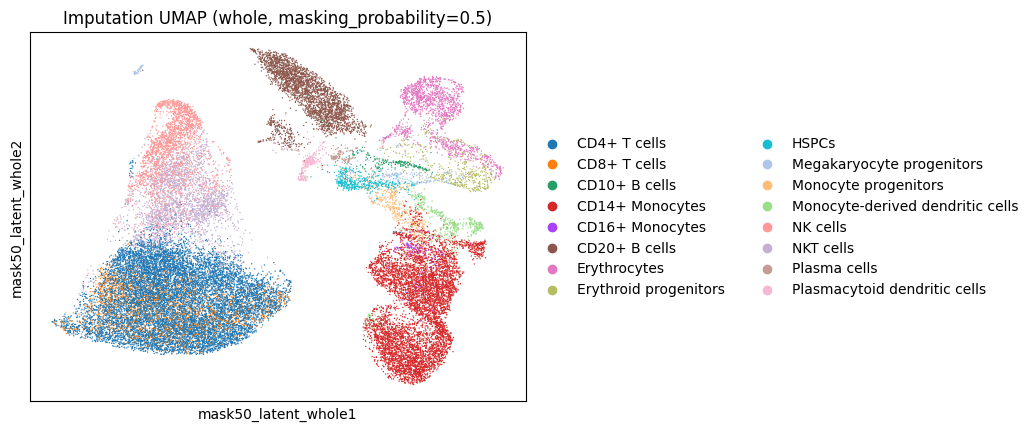

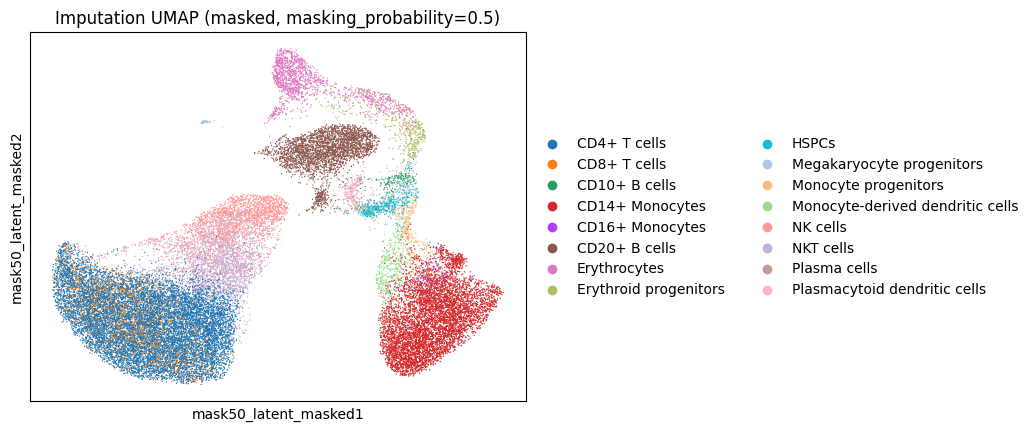

Saving celltype kNN expression correlation scores to CSV...


In [25]:
# Create UMAPs for each masking probability latent representation
celltype_score_df = pd.DataFrame()
#masking_probs = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.5, 0.7, 0.9]
masking_probs = [0.5]
for prob in masking_probs:
    # Read the anndata and pkl object for this masking probability
    adata = read_h5ad_file(f"runs/imputation_scvi/mask_{int(prob*100)}/imputation.h5ad")
    with open(f"runs/imputation_scvi/mask_{int(prob*100)}/predictions.pkl", "rb") as f:
        predictions = pickle.load(f)
    
    adata.obsm[f"mask{int(prob*100)}_latent_masked"] = predictions[f"mask{int(prob*100)}_latent_masked"]
    adata.obsm[f"mask{int(prob*100)}_latent_whole"] =  predictions[f"mask{int(prob*100)}_latent_whole"]

    latent_name = f"mask{int(prob*100)}_latent_whole"
    umap_name = f"mask{int(prob*100)}_latent_whole"
    
    # Compute kNN graph using the specified latent representation
    print(f"Computing kNN graph for masking probability {prob}...")
    sc.pp.neighbors(adata, use_rep=latent_name, n_neighbors=15, metric="euclidean", method="umap")

    # Compute kNN expression correlation scores
    print(f"Computing kNN expression correlations for masking probability {prob}...")
    correlations, distances_expr, jaccard_indices = compute_knn_expression_metrics(adata, use_rep=latent_name, n_top_neighbors=15)
    adata.obs["knn_expression_correlation"] = correlations
    adata.obs["knn_expression_distance"] = distances_expr
    adata.obs["knn_jaccard_index"] = jaccard_indices

    celltype_scores_corr = (adata.obs.groupby("final_annotation")["knn_expression_correlation"].mean())
    celltype_score_df[f"mask{int(prob*100)}_corr"] = celltype_scores_corr

    celltype_scores_dist = (adata.obs.groupby("final_annotation")["knn_expression_distance"].mean())
    celltype_score_df[f"mask{int(prob*100)}_dist"] = celltype_scores_dist

    celltype_scores_jaccard = (adata.obs.groupby("final_annotation")["knn_jaccard_index"].mean())
    celltype_score_df[f"mask{int(prob*100)}_jaccard"] = celltype_scores_jaccard

    # Compute UMAP
    print(f"Computing UMAP for masking probability {prob}...")
    sc.tl.umap(adata)
    adata.obsm[umap_name] = adata.obsm["X_umap"].copy()
    sc.pl.embedding(
        adata,
        basis=umap_name,
        color=["final_annotation"],
        ncols=1,
        title=f"Imputation UMAP (whole, masking_probability={prob})"
    )

    latent_name = f"mask{int(prob*100)}_latent_masked"
    umap_name = f"mask{int(prob*100)}_latent_masked"
    sc.pp.neighbors(adata, use_rep=latent_name, n_neighbors=30, metric="euclidean", method="umap")
    sc.tl.umap(adata)
    adata.obsm[umap_name] = adata.obsm["X_umap"].copy()
    sc.pl.embedding(
        adata,
        basis=umap_name,
        color=["final_annotation"],
        ncols=1,
        title=f"Imputation UMAP (masked, masking_probability={prob})"
    )

# Save celltype correlation scores to CSV
print("Saving celltype kNN expression correlation scores to CSV...")
celltype_score_df.to_csv("runs/imputation_scvi/celltype_knn_expression_scores.csv")


In [26]:
# get columns ending with corr from celltype_score_df
corr_columns = [col for col in celltype_score_df.columns if col.endswith('_corr')]
corr_df = celltype_score_df[corr_columns]

# get columns ending with dist from celltype_score_df
dist_columns = [col for col in celltype_score_df.columns if col.endswith('_dist')]
dist_df = celltype_score_df[dist_columns]

# get columns ending with jaccard from celltype_score_df
jaccard_columns = [col for col in celltype_score_df.columns if col.endswith('_jaccard')]
jaccard_df = celltype_score_df[jaccard_columns]

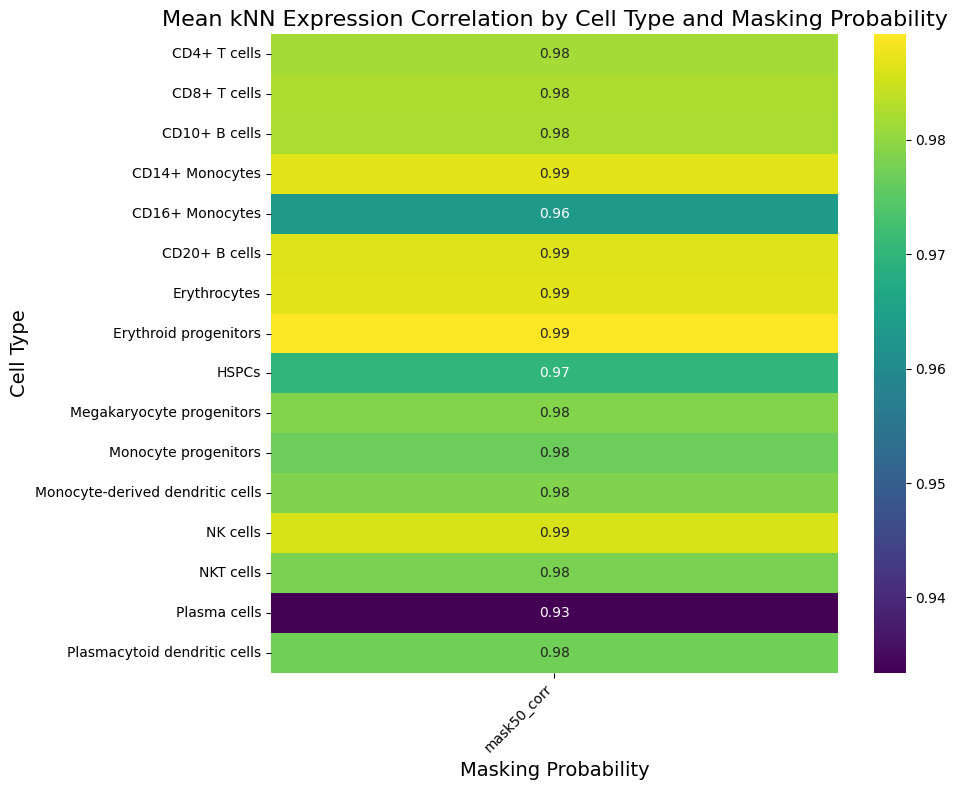

In [27]:
# Visualize celltype correlation scores as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="viridis")
plt.title("Mean kNN Expression Correlation by Cell Type and Masking Probability", fontsize=16)
plt.ylabel("Cell Type", fontsize=14)
plt.xlabel("Masking Probability", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

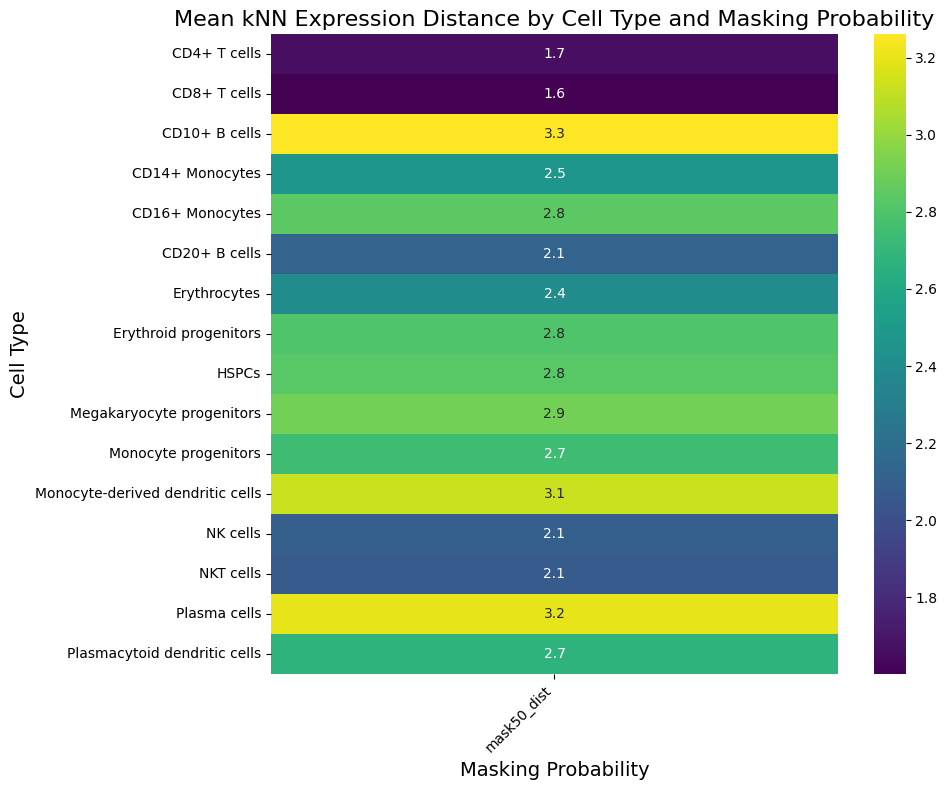

In [28]:
# Visualize celltype distance scores as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dist_df, annot=True, cmap="viridis")
plt.title("Mean kNN Expression Distance by Cell Type and Masking Probability", fontsize=16)
plt.ylabel("Cell Type", fontsize=14)
plt.xlabel("Masking Probability", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Plots of reconstruction loss, noise2self loss and KL divergence vs masking probability 

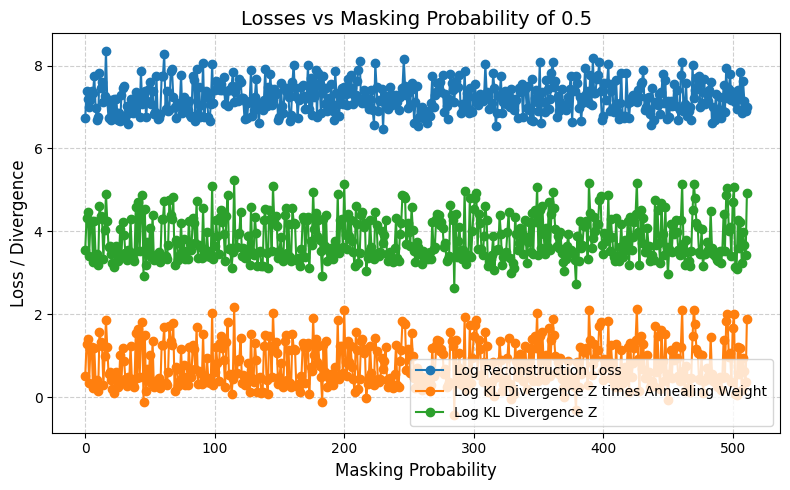

In [30]:
# Plot reconstruction loss, noise2self loss and KL divergence vs masking probability
# This is read from the saved output metrics during training
#masking_probs = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.5, 0.7, 0.9]
masking_probs = [0.5]
for prob in masking_probs:
    # Read the anndata and pkl object for this masking probability
    adata = read_h5ad_file(f"runs/imputation_scvi/mask_{int(prob*100)}/imputation.h5ad")
    with open(f"runs/imputation_scvi/mask_{int(prob*100)}/predictions.pkl", "rb") as f:
        predictions = pickle.load(f)

    metrics_reconstruction = predictions[f"mask{int(prob*100)}_output_metrics"]['reconstruction_loss']
    metrics_reconstruction = [m.item() for m in metrics_reconstruction]
   
    metrics_KL = predictions[f"mask{int(prob*100)}_output_metrics"]['kl_divergence_z']
    metrics_KL = [m.item() for m in metrics_KL]
    kl_annealing_weight = predictions[f"mask{int(prob*100)}_output_metrics"]['kl_annealing_weight']
    KL_weighted_metric = np.array(metrics_KL) * kl_annealing_weight
    
    # # plot line graph 
    plt.figure(figsize=(8, 5))
    plt.plot(np.log(metrics_reconstruction), marker='o', label='Log Reconstruction Loss')
    #plt.plot(np.log(metrics_noise2self), marker='o', label='Log Noise2Self Rec Loss')
    plt.plot(np.log(KL_weighted_metric), marker='o', label='Log KL Divergence Z times Annealing Weight')
    plt.plot(np.log(metrics_KL), marker='o', label='Log KL Divergence Z')
   
    # plt.plot(metrics_reconstruction, marker='o', label='Log Reconstruction Loss')
    # plt.plot(metrics_noise2self, marker='o', label='Log Noise2Self Rec Loss')
    # plt.plot(KL_weighted_metric, marker='o', label='Log KL Divergence Z')
    plt.xlabel('Masking Probability', fontsize=12)
    plt.ylabel('Loss / Divergence', fontsize=12)
    plt.title('Losses vs Masking Probability of ' + str(prob), fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# Reconstruct AnnData object from latent variables for both SCVI and imputation models

## UMAPs of reconstructed AnnData objects


Processing file: imputation_reconstructed_whole.h5ad


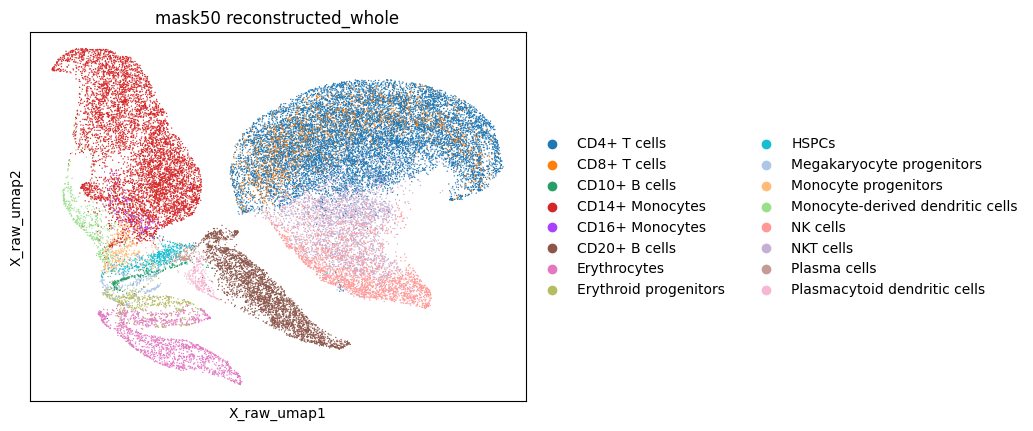


Processing file: imputation_reconstructed_masked.h5ad


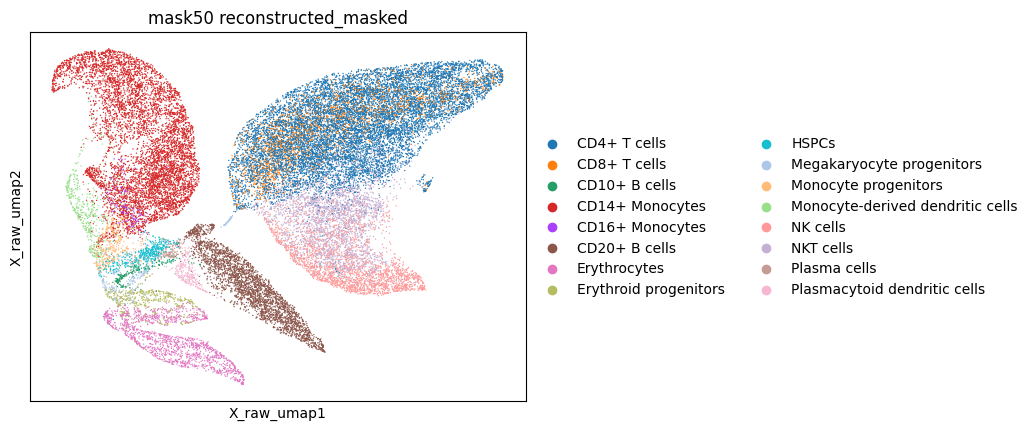

In [31]:
# read imputation_reconstructed_whole.h5ad, imputation_reconstructed_masked.h5ad, imputation_reconstructed_whole_old.h5ad and
# imputation_recontructed_masked_old.h5ad file in runs/imputation/mask_5 

# only for masked part? does it make a difference? 

#masking_probs = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.5, 0.7, 0.9]
masking_probs = [0.5]
for prob in masking_probs:
    outdir = f"runs/imputation_scvi/mask_{int(prob*100)}"
    name_label=f"mask{int(prob*100)}"
    # loop through these 4 files and for each one generate umap and plot
    for layer_file in ["imputation_reconstructed_whole.h5ad",
                       "imputation_reconstructed_masked.h5ad"]:
        
        print(f"\nProcessing file: {layer_file}")
        adata_reconstructed = read_h5ad_file(f"{outdir}/{layer_file}")
        layer_name = layer_file.replace(".h5ad", "").replace("imputation_", "").replace("_old", "")
        adata_reconstructed.X = adata_reconstructed.layers[layer_name]

        sc.pp.normalize_total(adata_reconstructed)
        sc.pp.log1p(adata_reconstructed)
        sc.pp.pca(adata_reconstructed)
        sc.pp.neighbors(adata_reconstructed, n_neighbors=15, metric="euclidean", method="umap")
        sc.tl.umap(adata_reconstructed)
        adata_reconstructed.obsm["X_raw_umap"] = adata_reconstructed.obsm["X_umap"].copy()
        
        title = layer_file.replace(".h5ad", "").replace("imputation_", "")
        title = name_label + " " + title
        sc.pl.embedding(adata_reconstructed, basis="X_raw_umap", color=["final_annotation"], ncols=1, title=title)